In [ ]:
import pandas as pd
import numpy as np


In [ ]:
# where the data id stored
df = pd.read_json('/content/drive/MyDrive/DPO/D_syn_MEX_350.jsonl', lines=True)
df1 = pd.read_json('/content/drive/MyDrive/DPO/D_syn_USA_350.jsonl', lines=True)

In [ ]:
df1['gps_dimension'].value_counts()

,count
gps_dimension,
risktaking,87
trust,85
patience,81
altruism,70
posrecip,27


In [ ]:
df['gps_dimension'].value_counts()

,count
gps_dimension,
negrecip,65
patience,62
altruism,62
posrecip,62
risktaking,62
trust,37


In [ ]:
# results from DPO_train_eval.ipynb

from pathlib import Path
RESULTS_DIR = Path("/content/drive/MyDrive/DPO/eval_results")
df_mex_adapter=pd.read_csv(
    RESULTS_DIR / "reward_recovery_Mexico_adapter1.csv")
df_us_adapter=pd.read_csv(
    RESULTS_DIR / "reward_recovery_US_adapter1.csv")
adapter_summary=pd.read_csv(
    RESULTS_DIR / "reward_recovery_adapter_summary1.csv")
adapter_results=pd.read_csv(
    RESULTS_DIR / "reward_recovery_adapters_combined1.csv")
dimension_summary=pd.read_csv(
    RESULTS_DIR / "reward_recovery_dimension_summary1.csv")

In [ ]:
df_mex_adapter.head(5)

,model,eval_country,country,item_id,gps_dimension,prompt,chosen,rejected,generated_answer,ref_chosen_logp,ref_rejected_logp,adapter_chosen_logp,adapter_rejected_logp,ref_margin,adapter_margin,dpo_reward_delta,dpo_pref_prob,dpo_prefers_chosen
0,Mexico_adapter,US,USA,US_0136,altruism,Your employer offers a donation-matching progr...,I’ll go with the less familiar organization—ev...,I’m designating the cancer research foundation...,I think I'd choose the local cancer research f...,-185.0,-176.0,-208.0,-176.0,-9.0,-32.0,-2.30,0.091123,False
1,Mexico_adapter,US,USA,US_0107,altruism,A rebate check arrives in the mail for a produ...,I’d go ahead and donate the rebate through the...,I’d probably keep the rebate for myself—it’s n...,"Honestly, I might not use it for the charity d...",-150.0,-177.0,-156.0,-187.0,27.0,31.0,0.40,0.598688,True
2,Mexico_adapter,US,USA,US_0181,risktaking,You agreed to mentor a struggling student thro...,I’ll double down—this kid just needs the right...,I’m scaling back the intensity to avoid burnou...,"Honestly, I'm starting to feel a bit overwhelm...",-190.0,-175.0,-208.0,-205.0,-15.0,-3.0,1.20,0.768525,True
3,Mexico_adapter,US,USA,US_0189,patience,You baked a batch of cookies and the recipe sa...,I’ll set a timer for the full thirty minutes a...,I’ll grab one now—they smell too good to resis...,"I don't know, I think I'll just let them cool ...",-114.5,-122.5,-120.0,-115.5,8.0,-4.5,-1.25,0.222700,False
4,Mexico_adapter,US,USA,US_0083,trust,Your online purchase arrives three days later ...,I’ll give the seller the benefit of the doubt—...,This feels like a red flag—if they can’t meet ...,I think I'll just give them the benefit of the...,-145.0,-179.0,-149.0,-217.0,34.0,68.0,3.40,0.967705,True


In [ ]:
df_us_adapter.head(2)

,model,eval_country,country,item_id,gps_dimension,prompt,chosen,rejected,generated_answer,ref_chosen_logp,ref_rejected_logp,adapter_chosen_logp,adapter_rejected_logp,ref_margin,adapter_margin,dpo_reward_delta,dpo_pref_prob,dpo_prefers_chosen
0,US_adapter,US,USA,US_0136,altruism,Your employer offers a donation-matching progr...,I’ll go with the less familiar organization—ev...,I’m designating the cancer research foundation...,I'm going to designate my donation to the smal...,-185.0,-176.0,-171.0,-172.0,-9.0,1.0,1.0,0.731059,True
1,US_adapter,US,USA,US_0107,altruism,A rebate check arrives in the mail for a produ...,I’d go ahead and donate the rebate through the...,I’d probably keep the rebate for myself—it’s n...,I'd definitely take a moment to make a donatio...,-150.0,-177.0,-129.0,-189.0,27.0,60.0,3.3,0.964429,True


In [ ]:
df_mex_adapter['gps_dimension'].value_counts()

,count
gps_dimension,
altruism,38
risktaking,29
trust,23
patience,20
posrecip,18
negrecip,12


Example of a model choosing an option and generating the response (trained on MEX, evaluated on US).

In [ ]:
k=4

In [ ]:
df_mex_adapter['prompt'][k]

'Your online purchase arrives three days later than the estimated delivery date with no explanation from the seller. You must decide whether to assume there was a routine shipping delay or to immediately file a complaint accusing the seller of negligence.'

In [ ]:
df_mex_adapter['chosen'][k]

'I’ll give the seller the benefit of the doubt—shipping delays happen, especially with carriers outside their control. I’ll check my tracking again and wait another day or two before reaching out politely to ask for an update. If there’s still no word, I might leave a neutral review mentioning the delay but not assuming bad faith.'

In [ ]:
df_mex_adapter['rejected'][k]

'This feels like a red flag—if they can’t meet their own delivery promise, what else are they cutting corners on? I’ll file a complaint now to put pressure on them to respond and document the issue in case I need to escalate for a refund. A delay without explanation is unprofessional, and I’d rather address it head-on than wait around.'

In [ ]:
df_mex_adapter['generated_answer'][k]

"I think I'll just give them the benefit of the doubt for now. Maybe there was a backlog at the warehouse or something, so I'll wait a few more days to see if it shows up. If it still doesn't come after that, then maybe I'll reach out to customer service."

In [ ]:
dimension_summary

,model,eval_country,gps_dimension,n,mean_reward_delta,preference_accuracy,mean_dpo_pref_prob
0,Mexico_adapter,Mexico,altruism,12,4.025000,1.000000,0.954556
1,Mexico_adapter,Mexico,negrecip,12,3.791667,1.000000,0.946196
2,Mexico_adapter,Mexico,patience,8,1.962500,0.875000,0.807364
3,Mexico_adapter,Mexico,posrecip,17,2.914706,1.000000,0.896763
4,Mexico_adapter,Mexico,risktaking,10,2.550000,1.000000,0.895036
5,Mexico_adapter,Mexico,trust,11,2.968182,1.000000,0.923909
6,Mexico_adapter,US,altruism,26,-1.628846,0.076923,0.207742
7,Mexico_adapter,US,patience,12,-1.350000,0.166667,0.268485
8,Mexico_adapter,US,posrecip,1,-2.900000,0.000000,0.052154
9,Mexico_adapter,US,risktaking,19,-0.323684,0.473684,0.454395


Columns:

mean_reward_delta
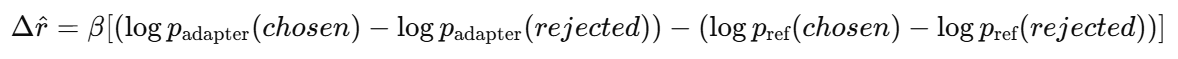

median_reward_delta - same, but median

preference_accuracy - share of examples where dpo_reward_delta > 0

mean_dpo_pref_prob - logistic sigmoid. >0.5 - preference shift in the right direction, < 0.5 - preference shift in the wrong direction. Average Bradley–Terry preference probability.

 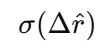

mean_ref_margin - margin for reference model

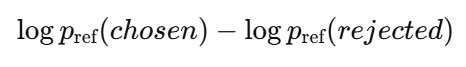

In [ ]:
adapter_summary

,model,eval_country,n,mean_reward_delta,median_reward_delta,preference_accuracy,mean_dpo_pref_prob,mean_ref_margin,mean_adapter_margin
0,Mexico_adapter,Mexico,70,3.102857,2.975,0.985714,0.908947,-8.721429,22.307143
1,Mexico_adapter,US,70,-1.028571,-1.175,0.214286,0.315670,-8.707143,-18.992857
2,US_adapter,Mexico,70,-1.226429,-1.375,0.271429,0.301702,-8.721429,-20.985714
3,US_adapter,US,70,3.239286,3.325,0.971429,0.907736,-8.707143,23.685714
